# 📈 MACD Crossover Strategy Backtest

## 🔹 Overview
This project implements and backtests the **MACD Crossover Strategy**, a widely used **trend-following trading system**.  
The strategy is based on the interaction between the **MACD line** and its **Signal line**:  
- When the **MACD crosses above** the Signal line → bullish momentum → **Buy**.  
- When the **MACD crosses below** the Signal line → bearish momentum → **Exit (Sell)**.  

The backtest evaluates this strategy against a **Buy & Hold benchmark** using synthetic stock data.

---

## 🔹 Technical Background

### MACD Components
1. **MACD Line**:  
\[
MACD = EMA_{12}(Close) - EMA_{26}(Close)
\]

2. **Signal Line**:  
\[
Signal = EMA_{9}(MACD)
\]

3. **Histogram**:  
\[
Hist = MACD - Signal
\]

---

## 🔹 Strategy Rules
- **Buy Signal**: MACD crosses **above** Signal line.  
- **Sell Signal**: MACD crosses **below** Signal line.  
- **Position**: Long-only (0 = flat, 1 = in position).  

---

## 🔹 Backtest Framework
The backtest computes:  
- **Equity Curve**: Growth of \$1 under strategy vs Buy & Hold.  
- **Performance Metrics**:  
  - **CAGR (Compound Annual Growth Rate)**  
  - **Sharpe Ratio** (risk-adjusted returns)  
  - **Max Drawdown (MDD)**  

### Formulas
- CAGR:  
\[
CAGR = \left(\frac{V_{end}}{V_{start}}\right)^{\tfrac{1}{T_{years}}} - 1
\]

- Sharpe Ratio:  
\[
Sharpe = \frac{E[R - R_f]}{\sigma_R} \times \sqrt{252}
\]

- Max Drawdown:  
\[
MDD = \min_t \frac{V_t - \max_{s \leq t} V_s}{\max_{s \leq t} V_s}
\]

---

## 🔹 Implementation Flow
```python
# 1. Load data
df = load_synthetic()

# 2. Compute MACD, Signal, Histogram
df = add_macd(df)

# 3. Apply MACD crossover strategy
df = macd_strategy(df)

# 4. Run backtest
backtest(df, "MACD Crossover")


In [2]:
print("Hello, World!")

Hello, World!


C:\Users\Viriya Gunawan Lim\AppData\Local\Temp\ipykernel_41900\3372147916.py:39: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  df["Position"] = df["Signal_Trade"].replace(to_replace=0, method="ffill").fillna(0)


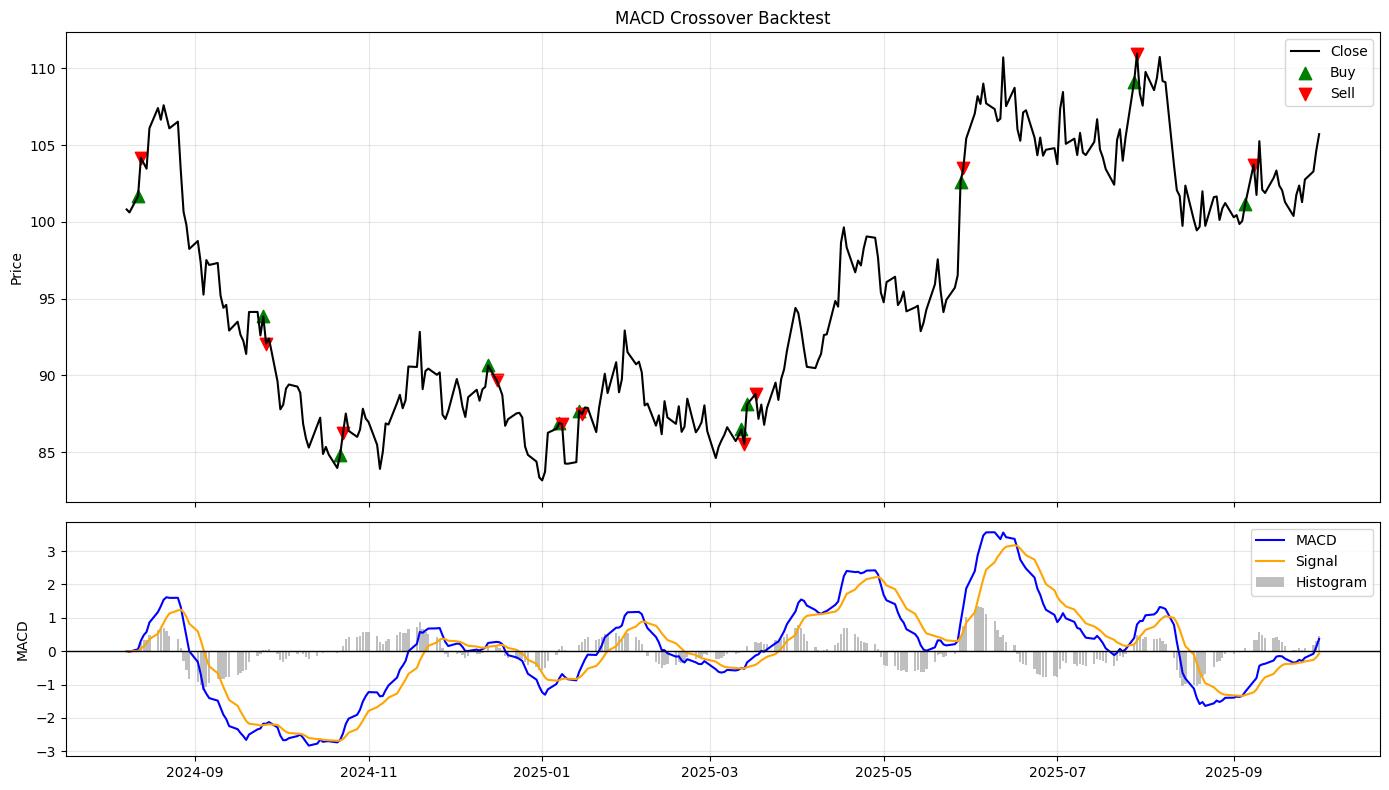

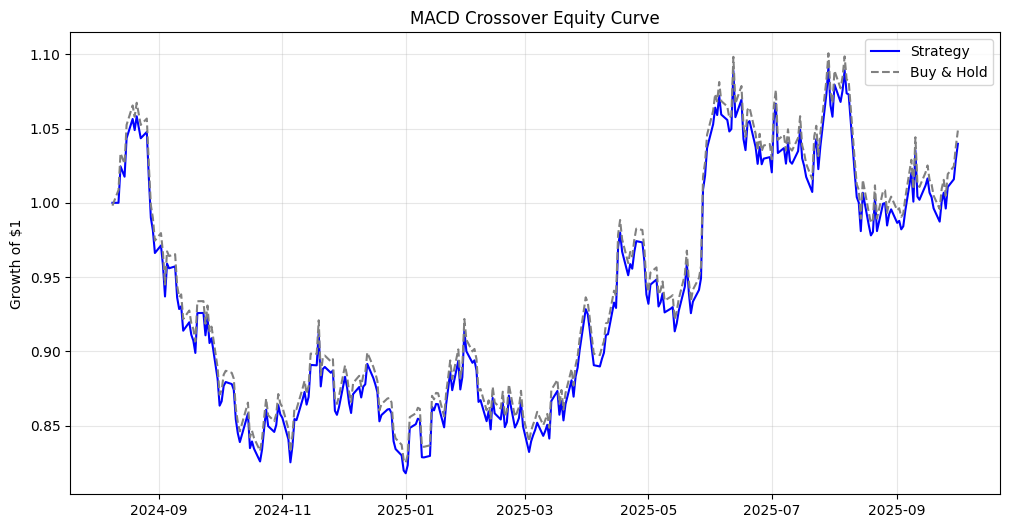

=== MACD Crossover Results ===
CAGR: nan%
Sharpe Ratio: 0.26
Max Drawdown: -22.72%


,High,Low,Close,Volume,MACD,Signal,Hist,Signal_Trade,Position,Return,Strat_Return,Equity_Strategy,Equity_BuyHold
2024-08-08,101.453853,99.617114,100.812819,4875754,0.000000,0.000000,0.000000,0,0,NaN,NaN,NaN,NaN
2024-08-09,101.060839,99.985104,100.620989,3704999,-0.015303,-0.003061,-0.012242,0,0,-0.001903,-0.000000,1.000000,0.998097
2024-08-12,103.232138,100.092042,101.680326,2103913,0.057388,0.009029,0.048359,1,1,0.010528,0.000000,1.000000,1.008605
2024-08-13,105.878274,103.702672,104.177077,3994200,0.312856,0.069795,0.243062,0,1,0.024555,0.024555,1.024555,1.033371
2024-08-14,105.879654,103.079627,103.821945,2324070,0.481115,0.152059,0.329056,0,1,-0.003409,-0.003409,1.021062,1.029849
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-25,101.887424,99.704883,101.289799,4007749,-0.292801,-0.334584,0.041784,0,1,-0.010583,-0.010583,0.996159,1.004731
2025-09-26,103.199474,102.452157,102.763053,4231959,-0.196875,-0.307042,0.110168,0,1,0.014545,0.014545,1.010648,1.019345
2025-09-29,104.705263,103.039009,103.289757,3366610,-0.077460,-0.261126,0.183666,0,1,0.005125,0.005125,1.015828,1.024570
2025-09-30,106.601611,103.096524,104.649054,2068199,0.125416,-0.183817,0.309234,0,1,0.013160,0.013160,1.029197,1.038053


In [1]:
# ==== MACD Crossover Backtest ====

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- Load Synthetic Data ----------------
def load_synthetic(n=300, seed=42):
    np.random.seed(seed)
    dates = pd.bdate_range(end=pd.Timestamp.today().normalize(), periods=n)
    mu, sigma, dt = 0.10, 0.25, 1/252
    z = np.random.normal(size=n)
    log_ret = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*z
    price = 100*np.exp(np.cumsum(log_ret))
    close = pd.Series(price, index=dates, name="Close")
    high = close * (1 + np.random.uniform(0.001, 0.02, size=n))
    low  = close * (1 - np.random.uniform(0.001, 0.02, size=n))
    volume = pd.Series(np.random.randint(1e6, 5e6, size=n), index=dates, name="Volume")
    df = pd.DataFrame({"High": high, "Low": low, "Close": close, "Volume": volume})
    return df

# ---------------- MACD Indicator ----------------
def add_macd(df, fast=12, slow=26, signal=9):
    df = df.copy()
    ema_fast = df["Close"].ewm(span=fast, adjust=False).mean()
    ema_slow = df["Close"].ewm(span=slow, adjust=False).mean()
    df["MACD"] = ema_fast - ema_slow
    df["Signal"] = df["MACD"].ewm(span=signal, adjust=False).mean()
    df["Hist"] = df["MACD"] - df["Signal"]
    return df

# ---------------- Strategy Rules ----------------
def macd_strategy(df):
    df = df.copy()
    df["Signal_Trade"] = 0
    df.loc[(df["MACD"] > df["Signal"]) & (df["MACD"].shift(1) <= df["Signal"].shift(1)), "Signal_Trade"] = 1
    df.loc[(df["MACD"] < df["Signal"]) & (df["MACD"].shift(1) >= df["Signal"].shift(1)), "Signal_Trade"] = 0
    # forward fill positions
    df["Position"] = df["Signal_Trade"].replace(to_replace=0, method="ffill").fillna(0)
    return df

# ---------------- Backtest ----------------
def backtest(df, strat_name="MACD Crossover"):
    df = df.copy().dropna()
    df["Return"] = df["Close"].pct_change()
    df["Strat_Return"] = df["Position"].shift(1) * df["Return"]

    df["Equity_Strategy"] = (1 + df["Strat_Return"]).cumprod()
    df["Equity_BuyHold"] = (1 + df["Return"]).cumprod()

    def CAGR(series):
        years = (series.index[-1] - series.index[0]).days / 365
        return (series.iloc[-1]/series.iloc[0])**(1/years) - 1 if years>0 else np.nan

    def sharpe(returns, rf=0.0):
        return (returns.mean() - rf) / returns.std() * np.sqrt(252)

    def max_drawdown(series):
        roll_max = series.cummax()
        dd = (series - roll_max) / roll_max
        return dd.min()

    cagr_strat = CAGR(df["Equity_Strategy"])
    sharpe_strat = sharpe(df["Strat_Return"].dropna())
    mdd_strat = max_drawdown(df["Equity_Strategy"])

    # Plot price with buy/sell markers
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14,8), sharex=True,
                                   gridspec_kw={'height_ratios':[2,1]})

    # Price + trades
    ax1.plot(df.index, df["Close"], label="Close", color="black")
    ax1.set_title(f"{strat_name} Backtest")
    ax1.set_ylabel("Price")
    buys = df.index[(df["Signal_Trade"] == 1)]
    sells = df.index[(df["Signal_Trade"] == 0) & (df["Signal_Trade"].shift(1) == 1)]
    ax1.scatter(buys, df.loc[buys,"Close"], marker="^", color="green", s=80, label="Buy")
    ax1.scatter(sells, df.loc[sells,"Close"], marker="v", color="red", s=80, label="Sell")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # MACD Panel
    ax2.plot(df.index, df["MACD"], label="MACD", color="blue")
    ax2.plot(df.index, df["Signal"], label="Signal", color="orange")
    ax2.bar(df.index, df["Hist"], label="Histogram", color="gray", alpha=0.5)
    ax2.axhline(0, color="black", linewidth=1)
    ax2.set_ylabel("MACD")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Equity Curve Plot
    fig, ax = plt.subplots(figsize=(12,6))
    ax.plot(df.index, df["Equity_Strategy"], label="Strategy", color="blue")
    ax.plot(df.index, df["Equity_BuyHold"], label="Buy & Hold", color="gray", linestyle="--")
    ax.set_title(f"{strat_name} Equity Curve")
    ax.set_ylabel("Growth of $1")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

    print(f"=== {strat_name} Results ===")
    print(f"CAGR: {cagr_strat:.2%}")
    print(f"Sharpe Ratio: {sharpe_strat:.2f}")
    print(f"Max Drawdown: {mdd_strat:.2%}")

    return df

# ---------------- Main ----------------
df = load_synthetic()
df = add_macd(df)
df = macd_strategy(df)
backtest(df, "MACD Crossover")
